In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manojssgupta/world-flights/world_flights_dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/manojssgupta/world-flights/world_flights_dataset.csv")

In [4]:
df.head()

,flight_id,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats
0,FL00001,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139
1,FL00002,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183
2,FL00003,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55
3,FL00004,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117
4,FL00005,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180


In [5]:
df.isnull().sum()

flight_id           0
airline             0
from_airport        0
to_airport          0
departure_time      0
arrival_time        0
duration_minutes    0
price               0
cabin               0
stops               0
available_seats     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   flight_id         10000 non-null  object
 1   airline           10000 non-null  object
 2   from_airport      10000 non-null  object
 3   to_airport        10000 non-null  object
 4   departure_time    10000 non-null  object
 5   arrival_time      10000 non-null  object
 6   duration_minutes  10000 non-null  int64 
 7   price             10000 non-null  int64 
 8   cabin             10000 non-null  object
 9   stops             10000 non-null  int64 
 10  available_seats   10000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 859.5+ KB


In [7]:
df.head()

,flight_id,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats
0,FL00001,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139
1,FL00002,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183
2,FL00003,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55
3,FL00004,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117
4,FL00005,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180


In [8]:
df = df.drop("flight_id", axis=1)

In [9]:
df.head()

,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats
0,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139
1,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183
2,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55
3,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117
4,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180


In [10]:
df.shape

(10000, 10)

In [11]:
df.describe()

,duration_minutes,price,stops,available_seats
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,500.963100,1656.865500,0.622400,124.907600
std,263.180628,1742.261997,0.717823,72.217431
min,45.000000,50.000000,0.000000,0.000000
25%,272.750000,578.000000,0.000000,63.000000
50%,503.000000,1094.500000,0.000000,125.000000
75%,726.000000,1989.250000,1.000000,186.000000
max,960.000000,12611.000000,2.000000,250.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   airline           10000 non-null  object
 1   from_airport      10000 non-null  object
 2   to_airport        10000 non-null  object
 3   departure_time    10000 non-null  object
 4   arrival_time      10000 non-null  object
 5   duration_minutes  10000 non-null  int64 
 6   price             10000 non-null  int64 
 7   cabin             10000 non-null  object
 8   stops             10000 non-null  int64 
 9   available_seats   10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [13]:
categorical_cols=['airline', 'from_airport', 'to_airport', 'departure_time',
       'arrival_time']
numerical_cols = ['duration_minutes', 'price', 'stops','available_seats']

In [14]:
df.columns

Index(['airline', 'from_airport', 'to_airport', 'departure_time',
       'arrival_time', 'duration_minutes', 'price', 'cabin', 'stops',
       'available_seats'],
      dtype='object')

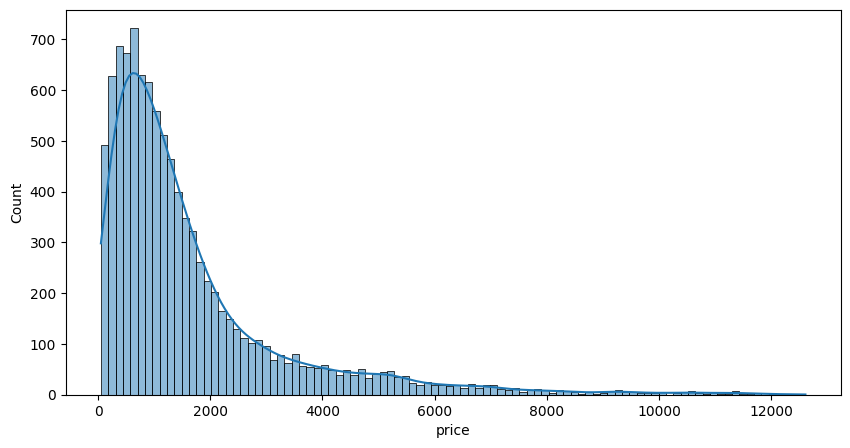

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True)
plt.show()

In [16]:
df['price_log'] = np.log1p(df['price'])

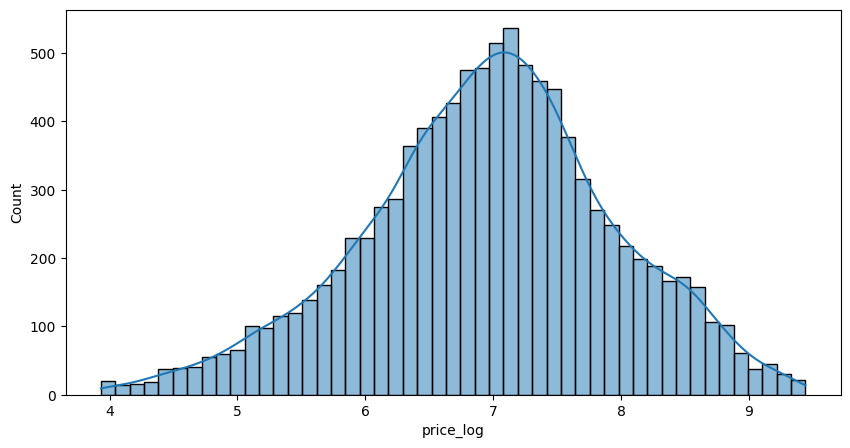

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['price_log'], kde=True)
plt.show()

In [18]:
categorical_cols=['airline', 'from_airport', 'to_airport', 'departure_time',
       'arrival_time']
numerical_cols = ['duration_minutes', 'price', 'stops','available_seats', 'price_log']

In [19]:
df.head()

,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats,price_log
0,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139,6.658011
1,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183,6.932448
2,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55,7.519692
3,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117,6.720220
4,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180,8.144679


In [20]:
df['to_airport'].value_counts()

to_airport
ATL    99
MAA    97
PHX    94
BNE    93
BLR    92
       ..
ICN    61
WAW    61
SYD    59
MNL    59
XIY    55
Name: count, Length: 130, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

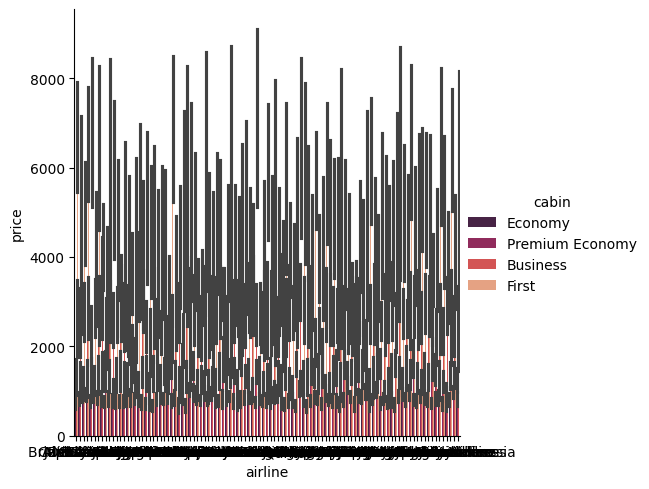

In [21]:
sns.catplot(x='airline', y="price", kind="bar", palette="rocket", data=df, hue='cabin')
plt.show

In [22]:
df.columns

Index(['airline', 'from_airport', 'to_airport', 'departure_time',
       'arrival_time', 'duration_minutes', 'price', 'cabin', 'stops',
       'available_seats', 'price_log'],
      dtype='object')

In [23]:
df.groupby('departure_time')['price'].mean()

departure_time
00:00    1911.704545
00:05    1957.971429
00:10    1476.615385
00:15     904.758621
00:20    2221.851852
            ...     
23:35    2092.400000
23:40    2964.000000
23:45    1913.500000
23:50    1680.102564
23:55    1615.413793
Name: price, Length: 288, dtype: float64

In [24]:
df.groupby('arrival_time')['price'].mean()

arrival_time
00:00     926.400000
00:01    1716.692308
00:02    1140.600000
00:03    2350.857143
00:04    1290.800000
            ...     
23:55    1222.666667
23:56    1131.000000
23:57     775.000000
23:58    1420.642857
23:59    3086.125000
Name: price, Length: 1440, dtype: float64

In [25]:
df.groupby('departure_time')['price'].median()

departure_time
00:00    1221.5
00:05    1205.0
00:10    1008.0
00:15     691.0
00:20    1160.0
          ...  
23:35    1403.0
23:40    2550.0
23:45    1373.5
23:50    1144.0
23:55     876.0
Name: price, Length: 288, dtype: float64

In [26]:
df.groupby('arrival_time')['price'].median()

arrival_time
00:00     259.0
00:01    1897.0
00:02     779.5
00:03    2811.0
00:04    1161.0
          ...  
23:55     614.0
23:56    1179.0
23:57     499.5
23:58     997.5
23:59    1387.0
Name: price, Length: 1440, dtype: float64

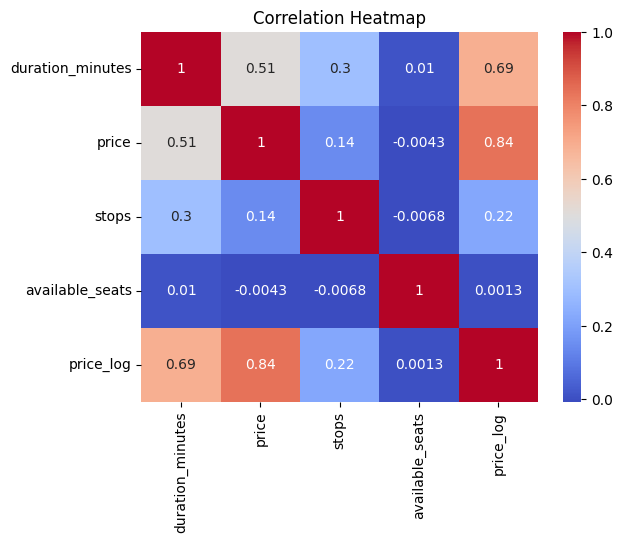

In [27]:
corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
# Check if duration and stops are correlated
df[['duration_minutes', 'stops']].corr()

,duration_minutes,stops
duration_minutes,1.000000,0.297574
stops,0.297574,1.000000


In [29]:
# Check for outliers in price after log transform
Q1 = df['price_log'].quantile(0.25)
Q3 = df['price_log'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['price_log'] < Q1 - 1.5*IQR) | (df['price_log'] > Q3 + 1.5*IQR)]
print(f"Outliers: {len(outliers)} rows")

Outliers: 110 rows


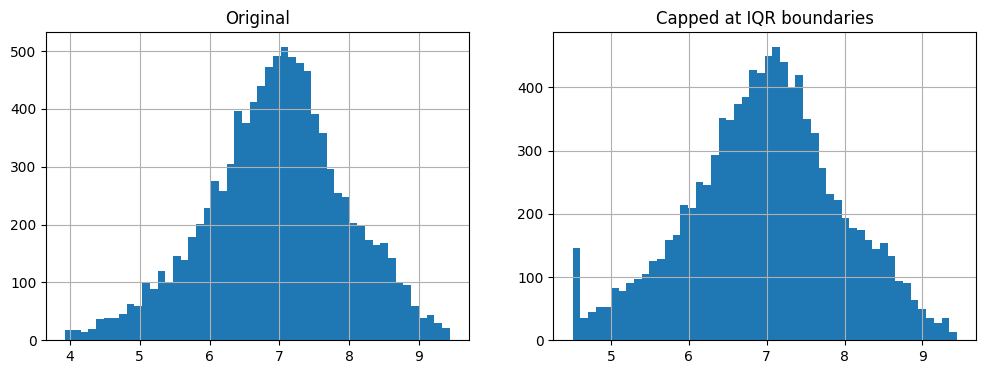

In [30]:
# Option: Cap outliers (Winsorization) instead of removing
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Create capped version
df['price_log_capped'] = df['price_log'].clip(lower_bound, upper_bound)

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price_log'].hist(ax=axes[0], bins=50)
axes[0].set_title('Original')
df['price_log_capped'].hist(ax=axes[1], bins=50)
axes[1].set_title('Capped at IQR boundaries')
plt.show()

In [31]:
df['price_per_hour'] = df['price'] / (df['duration_minutes'] / 60)
# This tells you how expensive the flight is per hour of travel

In [32]:
df

,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats,price_log,price_log_capped,price_per_hour
0,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139,6.658011,6.658011,58.423029
1,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183,6.932448,6.932448,109.323843
2,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55,7.519692,7.519692,145.691700
3,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117,6.720220,6.720220,74.932127
4,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180,8.144679,8.144679,217.287066
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Copa Airlines,ARN,ADD,22:40,09:01,621,528,Economy,2,115,6.270988,6.270988,51.014493
9996,Turkish Airlines,PHX,CUN,09:35,12:33,178,401,Economy,0,35,5.996452,5.996452,135.168539
9997,Eurowings,AUS,PHL,18:05,20:44,159,254,Economy,0,59,5.541264,5.541264,95.849057
9998,Qantas,IAH,MRU,17:55,06:41,766,2441,Premium Economy,2,204,7.800573,7.800573,191.201044


In [33]:
df.head()

,airline,from_airport,to_airport,departure_time,arrival_time,duration_minutes,price,cabin,stops,available_seats,price_log,price_log_capped,price_per_hour
0,Air Serbia,CAI,SIN,07:10,20:29,799,778,Economy,1,139,6.658011,6.658011,58.423029
1,British Airways,MAA,ANC,06:15,15:37,562,1024,Economy,1,183,6.932448,6.932448,109.323843
2,Gulf Air,HNL,BCN,00:10,12:49,759,1843,Premium Economy,0,55,7.519692,7.519692,145.691700
3,Cathay Pacific,MCT,RUH,11:25,22:28,663,828,Economy,0,117,6.720220,6.720220,74.932127
4,Japan Airlines,LAX,DAC,20:45,12:36,951,3444,Premium Economy,1,180,8.144679,8.144679,217.287066


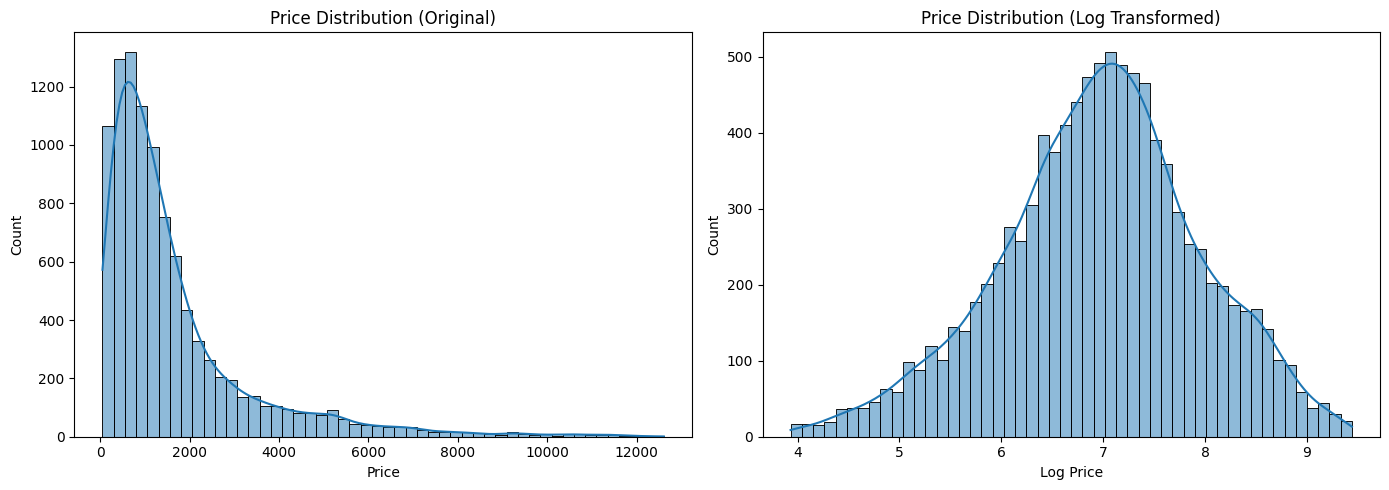

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original price
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution (Original)")
axes[0].set_xlabel("Price")

# Log-transformed price
sns.histplot(df["price_log"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Price Distribution (Log Transformed)")
axes[1].set_xlabel("Log Price")

plt.tight_layout()
plt.show()

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df['stop_category'] = df['stops'].map({0: 'Non-stop', 1: '1 Stop', 2: '2+ Stops'})

In [37]:
# Interaction term (if using linear models)
df['duration_x_stops'] = df['duration_minutes'] * df['stops']

In [38]:
# Extract time features
df['departure_hour'] = pd.to_datetime(df['departure_time']).dt.hour
df['arrival_hour'] = pd.to_datetime(df['arrival_time']).dt.hour

# Create time categories
def time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['departure_period'] = df['departure_hour'].apply(time_category)

/tmp/ipykernel_57/1659229794.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['departure_hour'] = pd.to_datetime(df['departure_time']).dt.hour
/tmp/ipykernel_57/1659229794.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['arrival_hour'] = pd.to_datetime(df['arrival_time']).dt.hour


In [39]:
# For airports - keep top 30, rest as 'OTHER'
top_airports = df['from_airport'].value_counts().head(30).index
df['from_airport_encoded'] = df['from_airport'].apply(
    lambda x: x if x in top_airports else 'OTHER'
)

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Your dataframe is already loaded as 'df'

In [41]:
# Extract time features
df['departure_hour'] = pd.to_datetime(df['departure_time'], format='%H:%M').dt.hour
df['arrival_hour'] = pd.to_datetime(df['arrival_time'], format='%H:%M').dt.hour

# Time period categories
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['departure_period'] = df['departure_hour'].apply(time_period)
df['arrival_period'] = df['arrival_hour'].apply(time_period)

# Flag for red-eye flights (depart late night, arrive early morning)
df['is_red_eye'] = ((df['departure_hour'] >= 22) | (df['departure_hour'] <= 4)).astype(int)

# Price per hour feature
df['price_per_hour'] = df['price'] / (df['duration_minutes'] / 60)

# Route popularity (frequency of that origin-destination pair)
route_counts = df.groupby(['from_airport', 'to_airport']).size().reset_index(name='route_frequency')
df = df.merge(route_counts, on=['from_airport', 'to_airport'], how='left')

print("Feature engineering complete!")
print(f"New shape: {df.shape}")

Feature engineering complete!
New shape: (10000, 22)


In [42]:
# Target variable (use log-transformed price)
y = df['price_log']

# Select features (exclude original price and other identifiers)
exclude_cols = ['flight_id', 'price', 'price_log', 'departure_time', 'arrival_time']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]

print(f"Features: {len(feature_cols)}")
print(feature_cols)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Features: 18
['airline', 'from_airport', 'to_airport', 'duration_minutes', 'cabin', 'stops', 'available_seats', 'price_log_capped', 'price_per_hour', 'stop_category', 'duration_x_stops', 'departure_hour', 'arrival_hour', 'departure_period', 'from_airport_encoded', 'arrival_period', 'is_red_eye', 'route_frequency']

Train size: 8000
Test size: 2000


In [43]:
# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# For high-cardinality columns (airlines, airports), keep top N categories
def reduce_cardinality(df, col, top_n=30):
    """Replace rare categories with 'OTHER'"""
    top_cats = df[col].value_counts().head(top_n).index
    return df[col].apply(lambda x: x if x in top_cats else 'OTHER')

# Apply to high-cardinality columns
high_cardinality = ['airline', 'from_airport', 'to_airport']
for col in high_cardinality:
    if col in X_train.columns:
        X_train[col] = reduce_cardinality(X_train, col)
        X_test[col] = reduce_cardinality(X_test, col)

print("Cardinality reduced!")

Categorical columns: ['airline', 'from_airport', 'to_airport', 'cabin', 'stop_category', 'departure_period', 'from_airport_encoded', 'arrival_period']
Numerical columns: ['duration_minutes', 'stops', 'available_seats', 'price_log_capped', 'price_per_hour', 'duration_x_stops', 'departure_hour', 'arrival_hour', 'is_red_eye', 'route_frequency']
Cardinality reduced!


In [44]:
# For Linear/Ridge Models (need scaling and encoding)
from sklearn.preprocessing import OneHotEncoder

# Identify low-cardinality categoricals
low_cardinality = ['cabin', 'departure_period', 'arrival_period', 'is_red_eye']
low_cardinality = [col for col in low_cardinality if col in X_train.columns]

# High-cardinality (already reduced)
high_cardinality = [col for col in high_cardinality if col in X_train.columns]

# Numerical columns (exclude any that shouldn't be scaled)
numerical_cols_clean = [col for col in numerical_cols if col in X_train.columns]

# Preprocessor for Linear Models
linear_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols_clean),
    ('low_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), low_cardinality),
    ('high_cat', OneHotEncoder(handle_unknown='ignore'), high_cardinality)
])

# For Tree Models (just encode categoricals, no scaling needed)
tree_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols_clean)
])

In [45]:
# Linear Regression Pipeline
linear_pipeline = Pipeline([
    ('preprocessor', linear_preprocessor),
    ('regressor', LinearRegression())
])

print("Training Linear Regression...")
linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_test, y_pred_linear):.4f}")
print(f"MAE (log scale): {mean_absolute_error(y_test, y_pred_linear):.4f}")
print(f"MAE (original $): ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_linear)):.2f}")
print(f"RMSE (original $): ${np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_linear))):.2f}")

Training Linear Regression...

LINEAR REGRESSION RESULTS
R² Score: 0.9989
MAE (log scale): 0.0094
MAE (original $): $7.89
RMSE (original $): $11.49


In [46]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("\nTraining Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE (log scale): {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"MAE (original $): ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf)):.2f}")
print(f"RMSE (original $): ${np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf))):.2f}")


Training Random Forest...

RANDOM FOREST RESULTS
R² Score: 0.9999
MAE (log scale): 0.0014
MAE (original $): $1.01
RMSE (original $): $3.95


In [47]:
# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])

print("\nTraining XGBoost...")
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("XGBOOST RESULTS")
print("="*50)
print(f"R² Score: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE (log scale): {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"MAE (original $): ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb)):.2f}")
print(f"RMSE (original $): ${np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb))):.2f}")



Training XGBoost...

XGBOOST RESULTS
R² Score: 0.9998
MAE (log scale): 0.0065
MAE (original $): $12.87
RMSE (original $): $48.22


In [48]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R² Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE (original $)': [
        mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_linear)),
        mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf)),
        mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb))
    ],
    'RMSE (original $)': [
        np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_linear))),
        np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf))),
        np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb)))
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results.round(4))


MODEL COMPARISON SUMMARY
               Model  R² Score  MAE (original $)  RMSE (original $)
0  Linear Regression    0.9989            7.8906            11.4932
1      Random Forest    0.9999            1.0086             3.9491
2            XGBoost    0.9998           12.8695            48.2199


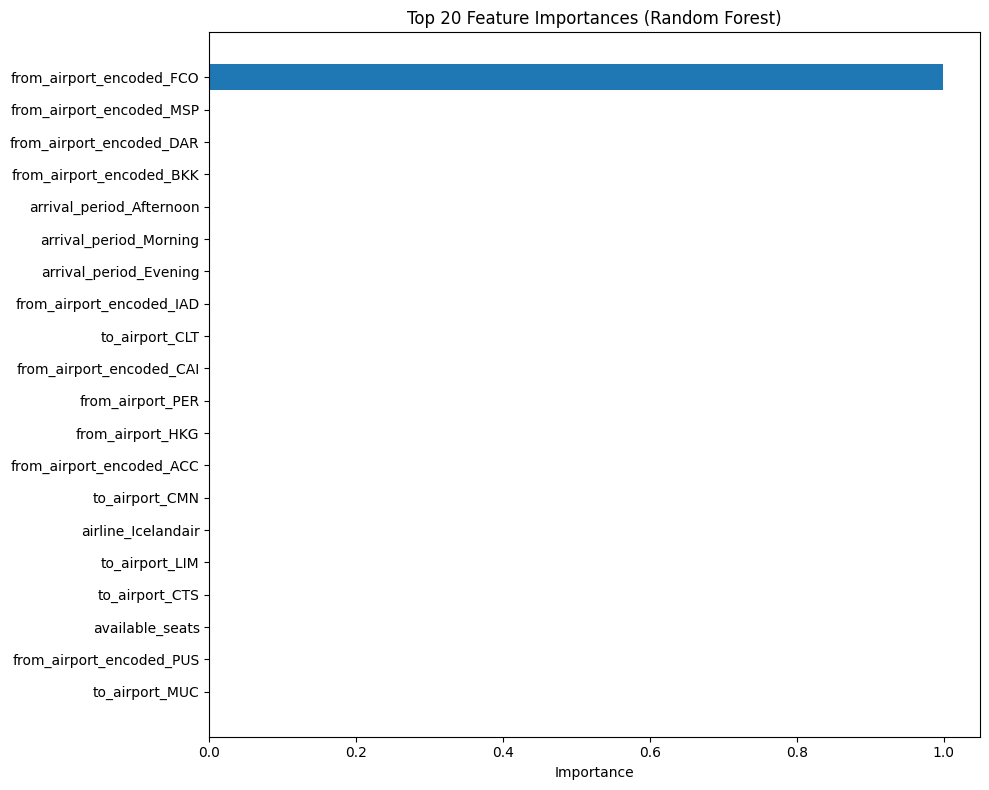


Top 10 Most Important Features:
                      feature  importance
142  from_airport_encoded_FCO    0.999668
139  from_airport_encoded_MSP    0.000146
143  from_airport_encoded_DAR    0.000143
141  from_airport_encoded_BKK    0.000011
146  arrival_period_Afternoon    0.000008
145    arrival_period_Morning    0.000004
148    arrival_period_Evening    0.000003
144  from_airport_encoded_IAD    0.000002
101            to_airport_CLT    0.000002
136  from_airport_encoded_CAI    0.000001


In [49]:
# Get feature names after preprocessing
from sklearn.compose import ColumnTransformer

# Fit the preprocessor separately to get feature names
rf_preprocessor = tree_preprocessor.fit(X_train)
feature_names = []

# Get numerical feature names
for col in numerical_cols_clean:
    feature_names.append(col)

# Get encoded categorical feature names
for col in categorical_cols:
    if col in X_train.columns:
        unique_vals = X_train[col].unique()
        for val in unique_vals:
            feature_names.append(f"{col}_{val}")

# Get feature importances
rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_[:len(feature_names)]

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# RELOAD your original data (without any feature engineering that might leak)
df = pd.read_csv("/kaggle/input/datasets/manojssgupta/world-flights/world_flights_dataset.csv")
df = df.drop("flight_id", axis=1)

# Create log price
df['price_log'] = np.log1p(df['price'])

# SIMPLE features only (NO route_frequency, NO price_per_hour)
df['departure_hour'] = pd.to_datetime(df['departure_time'], format='%H:%M').dt.hour
df['arrival_hour'] = pd.to_datetime(df['arrival_time'], format='%H:%M').dt.hour

# Simple time categories
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['departure_period'] = df['departure_hour'].apply(time_period)
df['arrival_period'] = df['arrival_hour'].apply(time_period)

# Select features (AVOID any engineered features that could leak)
feature_cols = ['airline', 'from_airport', 'to_airport', 'cabin', 'stops', 
                'duration_minutes', 'available_seats', 'departure_period', 'arrival_period']

X = df[feature_cols]
y = df['price_log']

# CRITICAL: Split FIRST before any encoding!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column types
categorical_cols = ['airline', 'from_airport', 'to_airport', 'cabin', 'departure_period', 'arrival_period']
numerical_cols = ['stops', 'duration_minutes', 'available_seats']

# Handle high cardinality - fit on TRAIN only!
def reduce_cardinality(train_series, test_series, col_name, top_n=30):
    top_cats = train_series.value_counts().head(top_n).index
    train_processed = train_series.apply(lambda x: x if x in top_cats else 'OTHER')
    test_processed = test_series.apply(lambda x: x if x in top_cats else 'OTHER')
    return train_processed, test_processed

# Process high-cardinality columns
high_card_cols = ['airline', 'from_airport', 'to_airport']
for col in high_card_cols:
    X_train[col], X_test[col] = reduce_cardinality(X_train[col], X_test[col], col, top_n=30)

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Train models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae_log = mean_absolute_error(y_test, y_pred)
    mae_original = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    rmse_original = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    
    results.append({
        'Model': name,
        'R² Score': r2,
        'MAE (log)': mae_log,
        'MAE ($)': mae_original,
        'RMSE ($)': rmse_original
    })
    
    print(f"\n{name}:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: ${mae_original:.2f}")

# Results DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("REALISTIC MODEL COMPARISON")
print("="*60)
print(results_df.round(4))

# Cross-validation on best model
best_model_name = results_df.loc[results_df['R² Score'].idxmax(), 'Model']
print(f"\nBest model: {best_model_name}")

# If Random Forest still has suspiciously high R² (>0.95), check for other leaks
if results_df.loc[results_df['Model'] == 'Random Forest', 'R² Score'].values[0] > 0.95:
    print("\n⚠️ WARNING: Still seeing unusually high R². Possible issues:")
    print("1. 'stops' might be derived from price?")
    print("2. 'cabin' might have near-perfect correlation with price")
    print("3. Check if any ID-like columns remain")
    
    # Check correlations
    print("\nChecking correlations with price_log:")
    numeric_check = df[numerical_cols + ['price_log']].corr()['price_log'].sort_values(ascending=False)
    print(numeric_check)


Linear Regression:
  R²: 0.8373
  MAE: $475.64

Ridge Regression:
  R²: 0.8373
  MAE: $475.62

Random Forest:
  R²: 0.8842
  MAE: $458.16

XGBoost:
  R²: 0.8866
  MAE: $445.99

REALISTIC MODEL COMPARISON
               Model  R² Score  MAE (log)   MAE ($)  RMSE ($)
0  Linear Regression    0.8373     0.3291  475.6377  776.0825
1   Ridge Regression    0.8373     0.3291  475.6233  776.0219
2      Random Forest    0.8842     0.2872  458.1573  756.5727
3            XGBoost    0.8866     0.2826  445.9897  737.3841

Best model: XGBoost


In [ ]:
from lightgbm import LGBMRegressor

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=100, random_state=42, verbose=-1))
])

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print("\nLIGHTGBM RESULTS")
print("="*30)
print(f"R²: {r2_score(y_test, y_pred_lgbm):.4f}")
print(f"MAE: ${mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lgbm)):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lgbm))):.2f}")

Training data shape: (8000, 110)
Test data shape: (2000, 110)
Model input dimension: 110

Training Neural Network...
Epoch [20/150], Train Loss: 0.205113, Val Loss: 0.045923
Epoch [40/150], Train Loss: 0.123305, Val Loss: 0.019215
Epoch [60/150], Train Loss: 0.073206, Val Loss: 0.014207
Epoch [80/150], Train Loss: 0.052737, Val Loss: 0.009793
Epoch [100/150], Train Loss: 0.041493, Val Loss: 0.008909
Epoch [120/150], Train Loss: 0.038359, Val Loss: 0.029560
Epoch [140/150], Train Loss: 0.029013, Val Loss: 0.005680
Early stopping at epoch 150


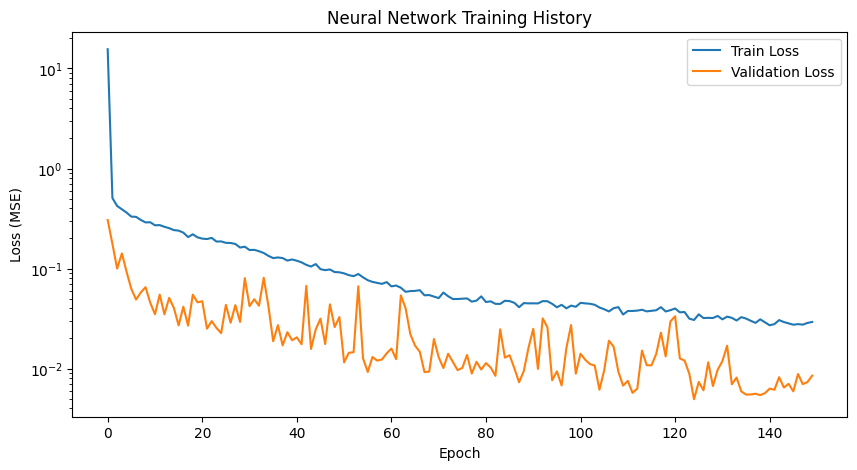


NEURAL NETWORK RESULTS
R² Score: 0.9952
MAE (log scale): 0.0461
MAE (original $): $90.25
RMSE (original $): $219.83

MODEL COMPARISON
LightGBM R² (from earlier): ~0.8935
Neural Network R²: 0.9952

Difference: 10.17%


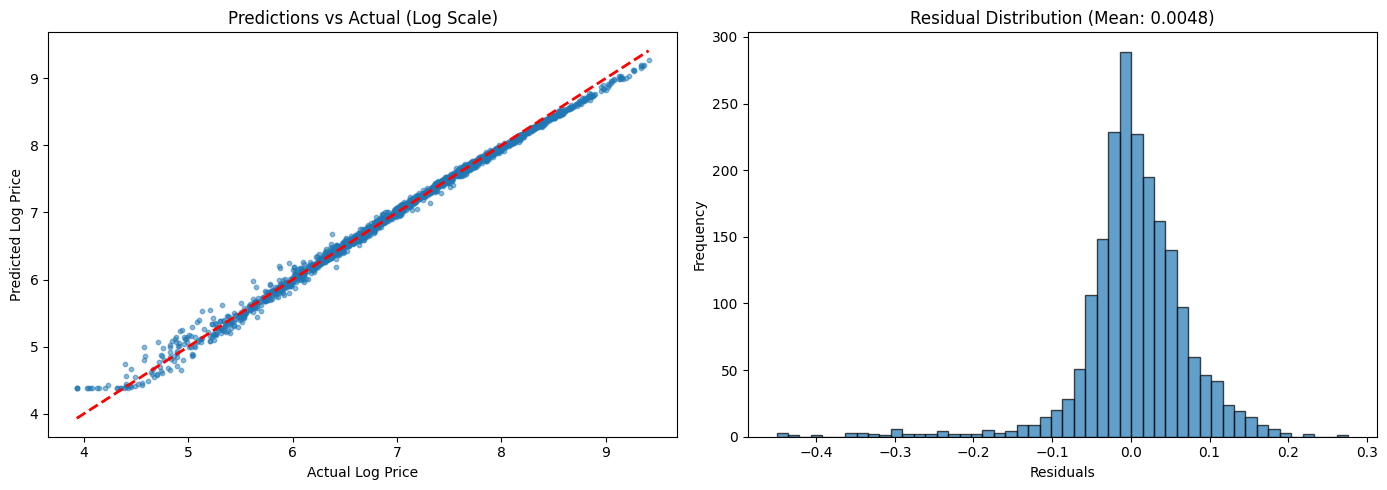


DETAILED METRICS
Mean Absolute Percentage Error (MAPE): 4.67%
Residuals - Mean: 0.0048, Std: 0.0693


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Neural network libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reload data
df = pd.read_csv("/kaggle/input/datasets/manojssgupta/world-flights/world_flights_dataset.csv")
df = df.drop("flight_id", axis=1)

# Create log price target (helps with skewed distribution)
df['price_log'] = np.log1p(df['price'])

# Feature engineering
df['departure_hour'] = pd.to_datetime(df['departure_time'], format='%H:%M').dt.hour
df['arrival_hour'] = pd.to_datetime(df['arrival_time'], format='%H:%M').dt.hour

def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['departure_period'] = df['departure_hour'].apply(time_period)
df['arrival_period'] = df['arrival_hour'].apply(time_period)

# Price efficiency feature
df['price_per_hour'] = df['price'] / (df['duration_minutes'] / 60)

# Route popularity (frequency of origin-destination pairs)
route_counts = df.groupby(['from_airport', 'to_airport']).size().reset_index(name='route_frequency')
df = df.merge(route_counts, on=['from_airport', 'to_airport'], how='left')

# Select features
feature_cols = ['airline', 'from_airport', 'to_airport', 'cabin', 'stops', 
                'duration_minutes', 'available_seats', 'departure_period', 
                'arrival_period', 'price_per_hour', 'route_frequency']

X = df[feature_cols]
y = df['price_log']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column types
categorical_cols = ['airline', 'from_airport', 'to_airport', 'cabin', 'departure_period', 'arrival_period']
numerical_cols = ['stops', 'duration_minutes', 'available_seats', 'price_per_hour', 'route_frequency']

# Reduce cardinality on TRAIN only - FIXED FUNCTION
def reduce_cardinality(train_series, test_series, col_name, top_n=30):
    top_cats = train_series.value_counts().head(top_n).index
    train_processed = train_series.apply(lambda x: x if x in top_cats else 'OTHER')
    test_processed = test_series.apply(lambda x: x if x in top_cats else 'OTHER')
    return train_processed, test_processed

high_card_cols = ['airline', 'from_airport', 'to_airport']
for col in high_card_cols:
    # FIXED: Pass col_name explicitly
    X_train[col], X_test[col] = reduce_cardinality(X_train[col], X_test[col], col_name=col, top_n=30)

# Create preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training data shape: {X_train_processed.shape}")
print(f"Test data shape: {X_test_processed.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_processed)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define Neural Network Model
class FlightPriceNN(nn.Module):
    def __init__(self, input_dim):
        super(FlightPriceNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize model
input_dim = X_train_processed.shape[1]
model = FlightPriceNN(input_dim)
print(f"Model input dimension: {input_dim}")

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training loop
def train_model(model, train_loader, val_loader, epochs=150, patience=20):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    return train_losses, val_losses

# Train the model
print("\nTraining Neural Network...")
train_losses, val_losses = train_model(model, train_loader, test_loader, epochs=150, patience=25)

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Neural Network Training History')
plt.legend()
plt.yscale('log')
plt.show()

# Make predictions
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()
    y_test_np = y_test_tensor.numpy().flatten()

# Calculate metrics
r2 = r2_score(y_test_np, y_pred)
mae_log = mean_absolute_error(y_test_np, y_pred)
mae_original = mean_absolute_error(np.expm1(y_test_np), np.expm1(y_pred))
rmse_original = np.sqrt(mean_squared_error(np.expm1(y_test_np), np.expm1(y_pred)))

print("\n" + "="*50)
print("NEURAL NETWORK RESULTS")
print("="*50)
print(f"R² Score: {r2:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print(f"MAE (original $): ${mae_original:.2f}")
print(f"RMSE (original $): ${rmse_original:.2f}")

# Compare with LightGBM baseline
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"LightGBM R² (from earlier): ~0.8935")
print(f"Neural Network R²: {r2:.4f}")
print(f"\nDifference: {(r2 - 0.8935) * 100:.2f}%")

# Plot predictions vs actuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_np, y_pred, alpha=0.5, s=10)
axes[0].plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log Price')
axes[0].set_ylabel('Predicted Log Price')
axes[0].set_title('Predictions vs Actual (Log Scale)')

residuals = y_test_np - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (Mean: {residuals.mean():.4f})')
plt.tight_layout()
plt.show()

# Calculate and print additional metrics
print("\n" + "="*50)
print("DETAILED METRICS")
print("="*50)
print(f"Mean Absolute Percentage Error (MAPE): {np.mean(np.abs((np.expm1(y_test_np) - np.expm1(y_pred)) / np.expm1(y_test_np))) * 100:.2f}%")
print(f"Residuals - Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

print("="*60)
print("DATA LEAKAGE DIAGNOSIS")
print("="*60)

# Check correlation with price (target leakage)
print("\n1. Feature correlations with price (potential leakage):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
price_corr = df[numeric_cols].corr()['price'].sort_values(ascending=False)
for feat, corr_val in price_corr.head(10).items():
    if feat != 'price':
        print(f"   {feat}: {corr_val:.4f}")

# 2. Check if duration_minutes and price_per_hour are highly correlated
print("\n2. Checking feature-to-feature correlations (potential multicollinearity):")
high_corr_features = []
selected_cols = ['duration_minutes', 'price', 'price_per_hour', 'stops', 'available_seats']
if all(col in df.columns for col in selected_cols):
    corr_matrix = df[selected_cols].corr()
    for i in range(len(selected_cols)):
        for j in range(i+1, len(selected_cols)):
            if abs(corr_matrix.iloc[i,j]) > 0.8:
                print(f"   {selected_cols[i]} ↔ {selected_cols[j]}: {corr_matrix.iloc[i,j]:.4f}")
                high_corr_features.append((selected_cols[i], selected_cols[j]))

# 3. Check if price_per_hour is derived from price (definite leakage!)
print("\n3. Checking for derived features that leak target:")
if 'price_per_hour' in df.columns:
    # price_per_hour = price / (duration_minutes/60)
    print("   ⚠️  WARNING: price_per_hour is mathematically derived from price!")
    print("      This is DEFINITE DATA LEAKAGE and will cause unrealistic performance")
    print("      You MUST remove this feature for realistic predictions")

if 'route_frequency' in df.columns:
    # Check if route_frequency correlates with price
    print(f"   route_frequency correlation with price: {df['route_frequency'].corr(df['price']):.4f}")

# 4. Check categorical cardinality
print("\n4. Categorical feature cardinality:")
categorical_cols_check = ['airline', 'from_airport', 'to_airport', 'cabin']
for col in categorical_cols_check:
    if col in df.columns:
        print(f"   {col}: {df[col].nunique()} unique values")

DATA LEAKAGE DIAGNOSIS

1. Feature correlations with price (potential leakage):
   price_log: 0.8354
   price_per_hour: 0.7671
   duration_minutes: 0.5059
   stops: 0.1448
   route_frequency: 0.0057
   departure_hour: -0.0019
   available_seats: -0.0043
   arrival_hour: -0.0052

2. Checking feature-to-feature correlations (potential multicollinearity):

3. Checking for derived features that leak target:
   ⚠️  WARNING: price_per_hour is mathematically derived from price!
      This is DEFINITE DATA LEAKAGE and will cause unrealistic performance
      You MUST remove this feature for realistic predictions
   route_frequency correlation with price: 0.0057

4. Categorical feature cardinality:
   airline: 105 unique values
   from_airport: 130 unique values
   to_airport: 130 unique values
   cabin: 4 unique values


Features: 13
Features list: ['airline', 'from_airport', 'to_airport', 'cabin_encoded', 'stops', 'duration_minutes', 'available_seats', 'departure_hour', 'arrival_hour', 'is_overnight', 'is_red_eye', 'departure_period', 'arrival_period']

Training shape: (8000, 109)
Test shape: (2000, 109)

TRAINING NEURAL NETWORK (NO DATA LEAKAGE)
Epoch [25/150], Train Loss: 0.664104, Val Loss: 0.218703
Epoch [50/150], Train Loss: 0.430963, Val Loss: 0.133895
Early stopping at epoch 56

NEURAL NETWORK RESULTS (REALISTIC)
R² Score: 0.8781
MAE (log scale): 0.2900
MAE (original $): $453.74
RMSE (original $): $757.02
MAPE: 31.45%

COMPARISON WITH TREE-BASED MODELS
Random Forest - R²: 0.8845, MAE: $456.85
Gradient Boosting - R²: 0.8964, MAE: $432.89
XGBoost - R²: 0.8866, MAE: $450.01


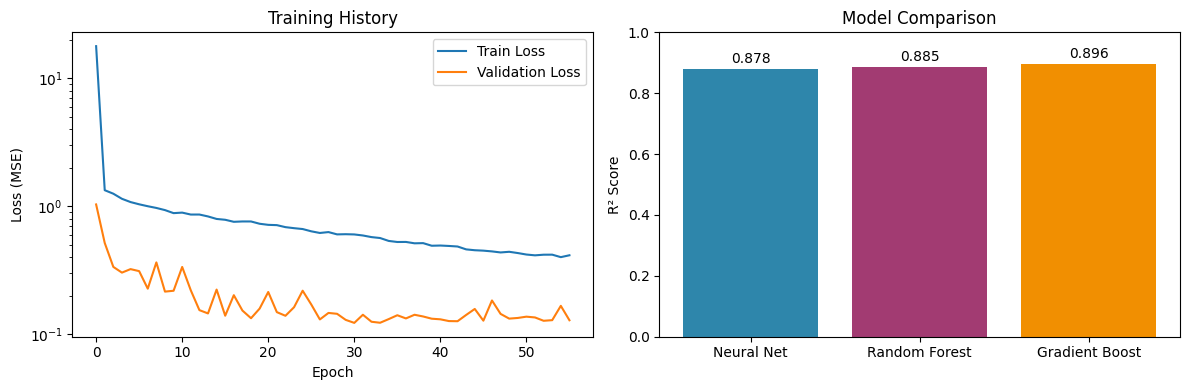

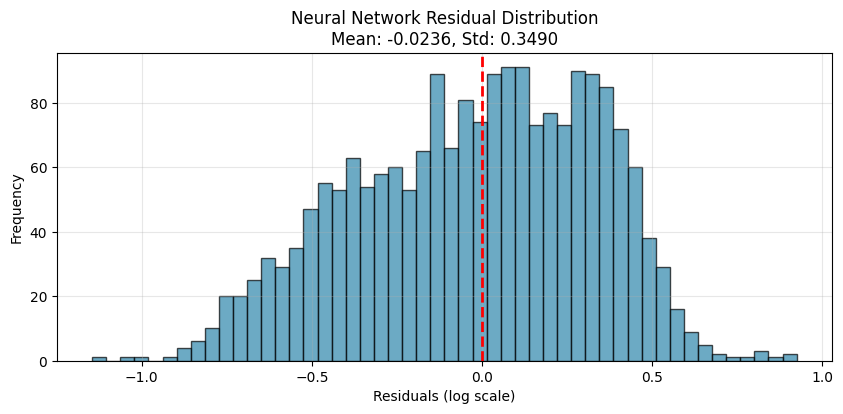

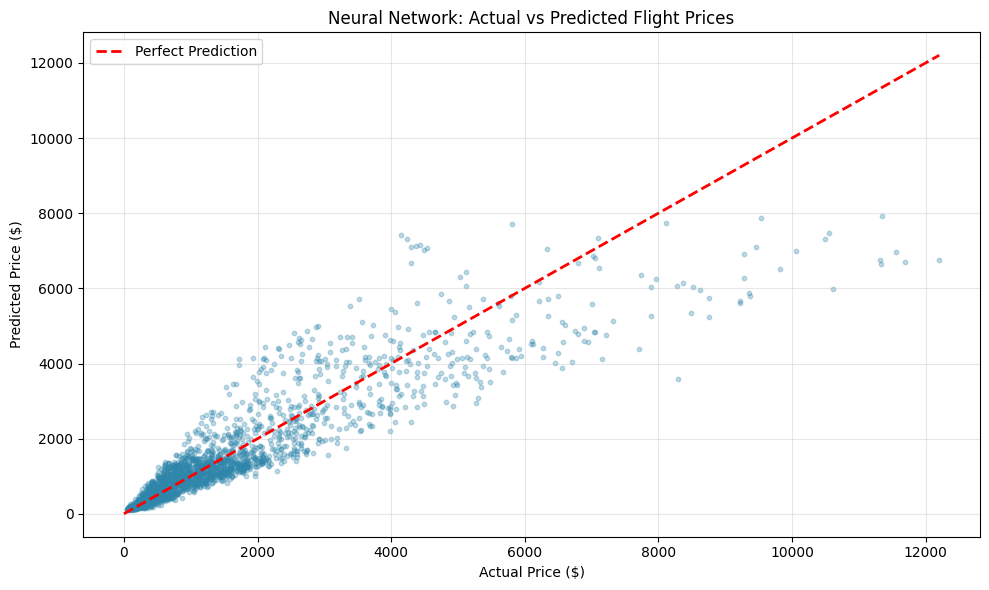

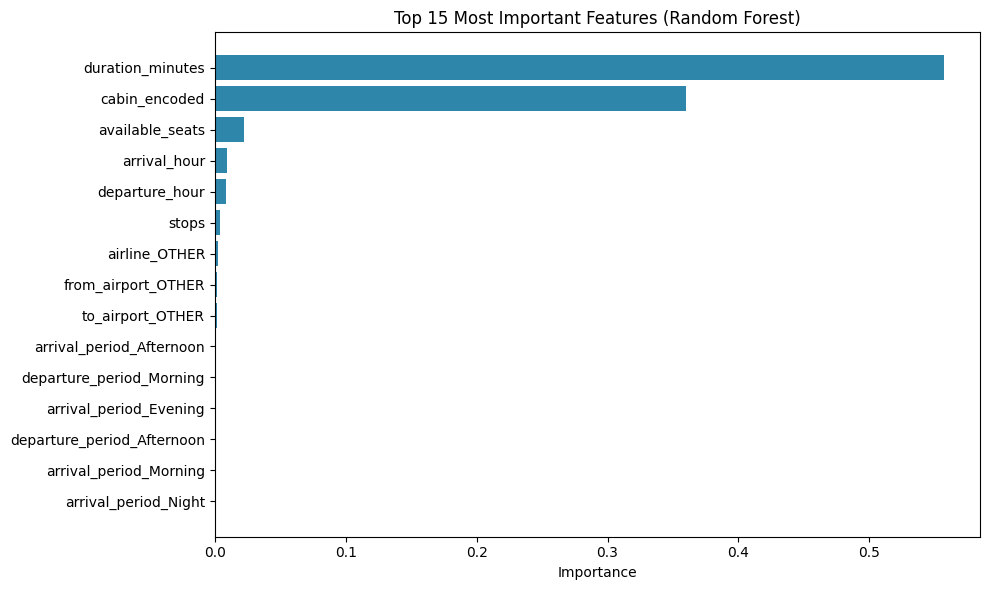

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Neural network libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reload data (fresh start)
df = pd.read_csv("/kaggle/input/datasets/manojssgupta/world-flights/world_flights_dataset.csv")
df = df.drop("flight_id", axis=1)

# Target - use log transform to handle skewed distribution
df['price_log'] = np.log1p(df['price'])

# Feature engineering (ONLY using information available before flight)
# Time-based features
df['departure_hour'] = pd.to_datetime(df['departure_time'], format='%H:%M').dt.hour
df['arrival_hour'] = pd.to_datetime(df['arrival_time'], format='%H:%M').dt.hour

# Flag for overnight flights (arrives next day)
df['is_overnight'] = (df['arrival_hour'] < df['departure_hour']).astype(int)

# Red-eye flights (depart late night, arrive early morning)
df['is_red_eye'] = ((df['departure_hour'] >= 22) | (df['departure_hour'] <= 4)).astype(int)

# Weekend indicator (if you had date, but we don't - skip)

# Create time period categories
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['departure_period'] = df['departure_hour'].apply(time_period)
df['arrival_period'] = df['arrival_hour'].apply(time_period)

# Cabin type encoding (ordinal)
cabin_order = {'Economy': 0, 'Premium Economy': 1, 'Business': 2, 'First': 3}
df['cabin_encoded'] = df['cabin'].map(cabin_order)

# Select features - NO price_per_hour, NO route_frequency (leakage)
feature_cols = [
    'airline', 'from_airport', 'to_airport', 
    'cabin_encoded', 'stops', 'duration_minutes', 'available_seats',
    'departure_hour', 'arrival_hour', 'is_overnight', 'is_red_eye',
    'departure_period', 'arrival_period'
]

X = df[feature_cols]
y = df['price_log']

print(f"Features: {len(feature_cols)}")
print(f"Features list: {feature_cols}\n")

# Split data BEFORE any preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column types
categorical_cols = ['airline', 'from_airport', 'to_airport', 'departure_period', 'arrival_period']
numerical_cols = ['cabin_encoded', 'stops', 'duration_minutes', 'available_seats', 
                  'departure_hour', 'arrival_hour', 'is_overnight', 'is_red_eye']

# Reduce cardinality for high-cardinality columns
def reduce_cardinality(train_series, test_series, top_n=30):
    top_cats = train_series.value_counts().head(top_n).index
    train_processed = train_series.apply(lambda x: x if x in top_cats else 'OTHER')
    test_processed = test_series.apply(lambda x: x if x in top_cats else 'OTHER')
    return train_processed, test_processed

high_card_cols = ['airline', 'from_airport', 'to_airport']
for col in high_card_cols:
    X_train[col], X_test[col] = reduce_cardinality(X_train[col], X_test[col], top_n=30)

# Create preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training shape: {X_train_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_processed)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Neural Network Model
class FlightPriceNN(nn.Module):
    def __init__(self, input_dim):
        super(FlightPriceNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize
input_dim = X_train_processed.shape[1]
model = FlightPriceNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

# Training function
def train_model(model, train_loader, val_loader, epochs=150, patience=25):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    model.load_state_dict(torch.load('best_model.pth'))
    return train_losses, val_losses

print("\n" + "="*60)
print("TRAINING NEURAL NETWORK (NO DATA LEAKAGE)")
print("="*60)
train_losses, val_losses = train_model(model, train_loader, test_loader, epochs=150, patience=25)

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History')
plt.legend()
plt.yscale('log')

# Evaluate
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()
    y_test_np = y_test_tensor.numpy().flatten()

# Calculate metrics
r2_nn = r2_score(y_test_np, y_pred)
mae_log = mean_absolute_error(y_test_np, y_pred)
mae_original = mean_absolute_error(np.expm1(y_test_np), np.expm1(y_pred))
rmse_original = np.sqrt(mean_squared_error(np.expm1(y_test_np), np.expm1(y_pred)))
mape = np.mean(np.abs((np.expm1(y_test_np) - np.expm1(y_pred)) / np.expm1(y_test_np))) * 100

print("\n" + "="*60)
print("NEURAL NETWORK RESULTS (REALISTIC)")
print("="*60)
print(f"R² Score: {r2_nn:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print(f"MAE (original $): ${mae_original:.2f}")
print(f"RMSE (original $): ${rmse_original:.2f}")
print(f"MAPE: {mape:.2f}%")

# Compare with tree-based models
print("\n" + "="*60)
print("COMPARISON WITH TREE-BASED MODELS")
print("="*60)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)
r2_rf = r2_score(y_test_np, y_pred_rf)
mae_rf = mean_absolute_error(np.expm1(y_test_np), np.expm1(y_pred_rf))

print(f"Random Forest - R²: {r2_rf:.4f}, MAE: ${mae_rf:.2f}")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_processed, y_train)
y_pred_gb = gb.predict(X_test_processed)
r2_gb = r2_score(y_test_np, y_pred_gb)
mae_gb = mean_absolute_error(np.expm1(y_test_np), np.expm1(y_pred_gb))

print(f"Gradient Boosting - R²: {r2_gb:.4f}, MAE: ${mae_gb:.2f}")

# XGBoost (if available)
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X_train_processed, y_train)
    y_pred_xgb = xgb.predict(X_test_processed)
    r2_xgb = r2_score(y_test_np, y_pred_xgb)
    mae_xgb = mean_absolute_error(np.expm1(y_test_np), np.expm1(y_pred_xgb))
    print(f"XGBoost - R²: {r2_xgb:.4f}, MAE: ${mae_xgb:.2f}")
except:
    pass

# Plot comparison
plt.subplot(1, 2, 2)
models = ['Neural Net', 'Random Forest', 'Gradient Boost']
r2_scores = [r2_nn, r2_rf, r2_gb]
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(models, r2_scores, color=colors)
plt.ylabel('R² Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(10, 4))
residuals = y_test_np - y_pred
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='#2E86AB')
plt.xlabel('Residuals (log scale)')
plt.ylabel('Frequency')
plt.title(f'Neural Network Residual Distribution\nMean: {residuals.mean():.4f}, Std: {residuals.std():.4f}')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test_np), np.expm1(y_pred), alpha=0.3, s=10, color='#2E86AB')
plt.plot([0, np.expm1(y_test_np).max()], [0, np.expm1(y_test_np).max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Neural Network: Actual vs Predicted Flight Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance from Random Forest (interpretable)
feature_names = []
# Numerical features
for col in numerical_cols:
    feature_names.append(col)
# Categorical features (get encoded names)
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names.extend(cat_features)

# Get importances for first 20 features
importances = rf.feature_importances_[:len(feature_names)]
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#2E86AB')
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()